> Projeto Desenvolve <br>
Programação Intermediária com Python <br>
Profa. Camila Laranjeira (mila@projetodesenvolve.com.br) <br>

# 3.9 - Visualização de Dados

## Exercícios
Vamos trabalhar com as mesmas bases de dados do exercício de Pandas. Aqui estão os links caso você queira baixar novamente, mas recomendo trabalhar com o `wc_formatado.csv` que exportamos na questão Q2 do exercício anterior.

* https://raw.githubusercontent.com/camilalaranjeira/python-intermediario/main/fifa-wc/matches_1930_2022.csv
* https://raw.githubusercontent.com/camilalaranjeira/python-intermediario/main/fifa-wc/matches_1991_2023.csv

Para relembrar, essas são as colunas do dataframe:
```
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time_1             1312 non-null   string        
 1   time_2             1312 non-null   string        
 2   gols_1             1312 non-null   int64         
 3   gols_2             1312 non-null   int64         
 4   data               1312 non-null   datetime64[ns]
 5   ano                1312 non-null   int64         
 6   país_sede          1312 non-null   string        
 7   comparecimento     1312 non-null   int64         
 8   resultado          1312 non-null   string        
 9   rodada             1312 non-null   category      
 10  gols_1_detalhes    970 non-null    string        
 11  gols_2_detalhes    771 non-null    string        
 12  gols_1_contra      57 non-null     string        
 13  gols_2_contra      30 non-null     string        
 14  gols_1_penalti     170 non-null    string        
 15  gols_2_penalti     119 non-null    string        
 16  cartao_vermelho_1  59 non-null     string        
 17  cartao_vermelho_2  65 non-null     string        
 18  cartao_amarelo_1   834 non-null    string        
 19  cartao_amarelo_2   857 non-null    string        
 20  copa               1312 non-null   string 
```

#### Q1.
Realize todos os imports necessários para executar as três bibliotecas de visualização que conhecemos:
* Matplotlib (lembre-se do comando mágico)
* Seaborn
* Plotly

Para cada uma delas, altere o tema padrão de visualização. 

In [1]:
import numpy as np
import pandas as pd
import ast

# matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# seaborn
import seaborn as sns
sns.set_theme(style='darkgrid')

# plotly
import plotly.express as px
import plotly.io as pio
pio.templates.default = 'plotly_dark'

# recarregando os dados já formatados na Q1 do exercício de pandas
wc = pd.read_csv('wc_formatado.csv', index_col=0)
wc['data'] = pd.to_datetime(wc['data'])

colunas_string = ['time_1', 'time_2', 'país_sede', 'resultado',
                   'gols_1_detalhes', 'gols_2_detalhes', 'gols_1_contra', 'gols_2_contra',
                   'gols_1_penalti', 'gols_2_penalti', 'cartao_vermelho_1', 'cartao_vermelho_2',
                   'cartao_amarelo_1', 'cartao_amarelo_2', 'copa']
wc[colunas_string] = wc[colunas_string].astype('string')
wc['rodada'] = wc['rodada'].astype('category')

wc.head()


,time_1,time_2,gols_1,gols_2,data,ano,país_sede,comparecimento,resultado,rodada,...,gols_2_detalhes,gols_1_contra,gols_2_contra,gols_1_penalti,gols_2_penalti,cartao_vermelho_1,cartao_vermelho_2,cartao_amarelo_1,cartao_amarelo_2,copa
0,Spain,England,1,0,2023-08-20,2023,"Australia, New Zealand",75784,1–0,Final,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,['78’|1:0|Salma Paralluelo'],['55’|1:0|Lauren Hemp'],Feminina
1,Sweden,Australia,2,0,2023-08-19,2023,"Australia, New Zealand",49461,2–0,Third-place match,...,<NA>,<NA>,<NA>,Fridolina Rolfö (P) · 30’,<NA>,<NA>,<NA>,"['88’|2:0|Elin Rubensson', '90+5’|2:0|Lina Hur...",['45+1’|1:0|Katrina Gorry'],Feminina
2,Australia,England,1,3,2023-08-16,2023,"Australia, New Zealand",75784,1–3,Semi-finals,...,Ella Toone · 36’|Lauren Hemp · 71’|Alessia Rus...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"['10’|0:0|Alex Greenwood', '90+5’|1:3|Chloe Ke...",Feminina
3,Spain,Sweden,2,1,2023-08-15,2023,"Australia, New Zealand",43217,2–1,Semi-finals,...,Rebecka Blomqvist · 88’,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Feminina
4,Australia,France,0,0,2023-08-12,2023,"Australia, New Zealand",49461,(7) 0–0 (6),Quarter-finals,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,['92’|0:0|Katrina Gorry'],<NA>,Feminina


#### Q2.
Sobre os dados de copa do mundo, qual a distribuição de público presente nos jogos? Isso pode ser respondido com um histograma com os dados da coluna `comparecimento`.  

Lembre-se que alguns jogos estavam com público 0 incorretamente, que tal remover essas ocorrências para não atrapalhar sua visualzação?

Você deve implementar essa visualização nas três bibliotecas que vimos:
* Matplotlib
* Seaborn
* Plotly

Garanta que o gráfico tenha pelo menos os atributos de título e rótulos de dimensão.

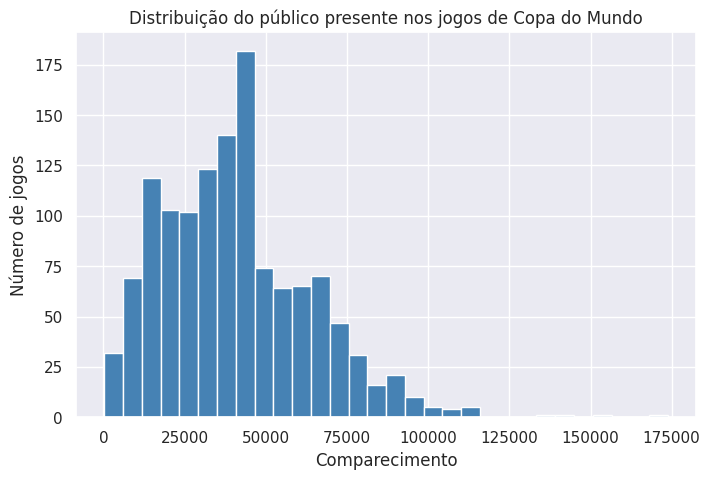

In [2]:
#### solução com matplotlib

# tira os jogos com público 0, que são erro de cadastro
publico = wc[wc['comparecimento'] > 0]['comparecimento']

plt.figure(figsize=(8, 5))
plt.hist(publico, bins=30, color='steelblue', edgecolor='white')
plt.title('Distribuição do público presente nos jogos de Copa do Mundo')
plt.xlabel('Comparecimento')
plt.ylabel('Número de jogos')
plt.show()


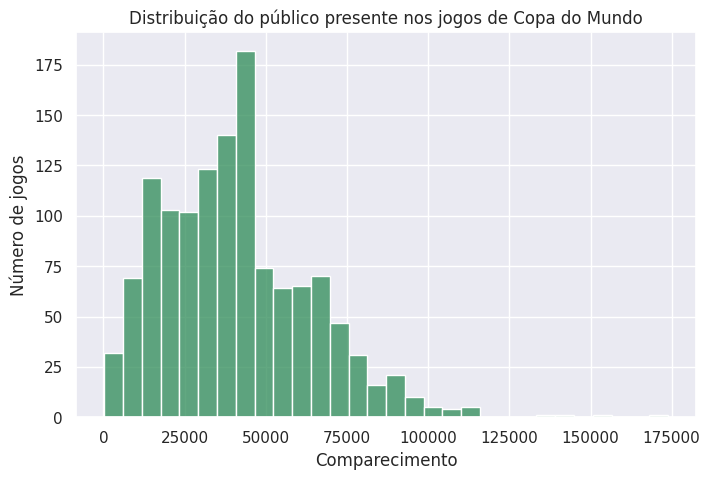

In [3]:
#### solução com seaborn

plt.figure(figsize=(8, 5))
sns.histplot(publico, bins=30, color='seagreen')
plt.title('Distribuição do público presente nos jogos de Copa do Mundo')
plt.xlabel('Comparecimento')
plt.ylabel('Número de jogos')
plt.show()


In [4]:
#### solução com plotly

fig = px.histogram(publico, nbins=30, title='Distribuição do público presente nos jogos de Copa do Mundo')
fig.update_layout(xaxis_title='Comparecimento', yaxis_title='Número de jogos')
fig.show()


#### Q3.

Apresente um gráfico de dispersão (scatter) dos atributos `gols_1` e `gols_2`. Isso representa a relação entre gols feitos e gols tomados por jogo. Há alguma relação interessante entre esses atributos?

Para facilitar a visualização dos dados (já que tem muitos placares repetidos), aplique uma leve distorção aos dados para que cada ponto esteja deslocado aleatoriamente de seu valor original. Código apresentado a seguir
```python
gols = wc[['gols_1', 'gols_2']] * np.random.random((len(wc),2))
```

Você deve implementar essa visualização nas três bibliotecas que vimos:
* Matplotlib
* Seaborn
* Plotly

Garanta que o gráfico tenha pelo menos os atributos de título e rótulos de dimensão.

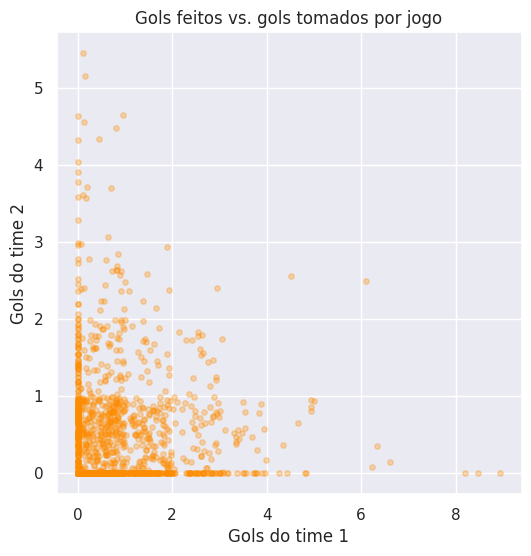

In [5]:
#### solução com matplotlib

np.random.seed(42)
gols_jitter = wc[['gols_1', 'gols_2']] * np.random.random((len(wc), 2))

plt.figure(figsize=(6, 6))
plt.scatter(gols_jitter['gols_1'], gols_jitter['gols_2'], alpha=0.3, s=15, color='darkorange')
plt.title('Gols feitos vs. gols tomados por jogo')
plt.xlabel('Gols do time 1')
plt.ylabel('Gols do time 2')
plt.show()

# a maior parte dos pontos fica concentrada perto da origem e ao redor da diagonal,
# ou seja, a maioria dos jogos termina com placares baixos e relativamente equilibrados.
# goleadas (muitos gols de um lado só) são bem mais raras.


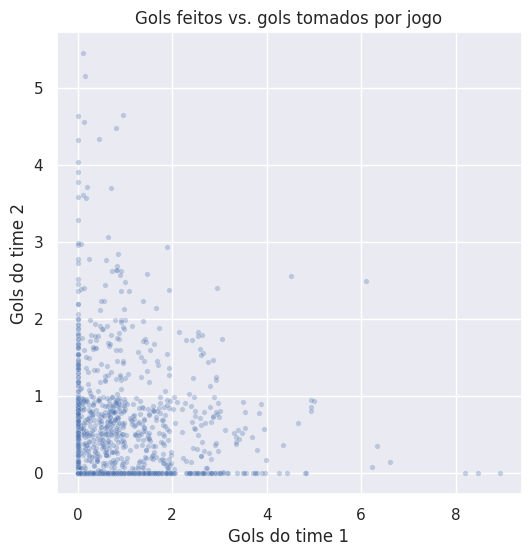

In [6]:
#### solução com seaborn

plt.figure(figsize=(6, 6))
sns.scatterplot(x=gols_jitter['gols_1'], y=gols_jitter['gols_2'], alpha=0.3, s=15)
plt.title('Gols feitos vs. gols tomados por jogo')
plt.xlabel('Gols do time 1')
plt.ylabel('Gols do time 2')
plt.show()


In [7]:
#### solução com plotly

fig = px.scatter(gols_jitter, x='gols_1', y='gols_2', opacity=0.3,
                  title='Gols feitos vs. gols tomados por jogo')
fig.update_layout(xaxis_title='Gols do time 1', yaxis_title='Gols do time 2')
fig.show()


#### Q4.

Apresente um gráfico de barras com o top 10 países que mais participaram de copas do mundo, onde no eixo x devem estar o nome dos países e no eixo y a contagem de participações. Você deve separar a contagem de participações em copas femininas e masculinas, empilhando as barras de cada informação.

No exemplo de barras empilhadas da galeria do matplotlib, imagine que a parte azul são as participações do país em copas masculinas, e em laranja as participações femininas:
* https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_stacked.html

Você deve implementar essa visualização nas três bibliotecas que vimos:
* Matplotlib
* Seaborn
* Plotly

Garanta que o gráfico tenha pelo menos os atributos:
* título
* rótulos de dimensão.
* legenda

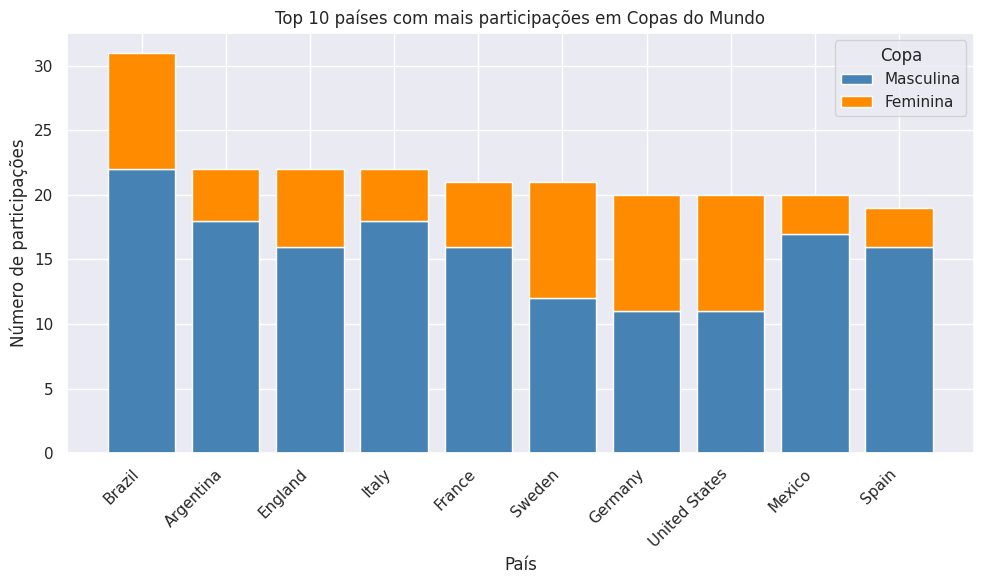

In [8]:
#### solução com matplotlib

# recalcula a participação de cada país em copas (masculina/feminina),
# igual fizemos no exercício de pandas
times_casa = wc[['time_1', 'ano', 'copa']].rename(columns={'time_1': 'país'})
times_fora = wc[['time_2', 'ano', 'copa']].rename(columns={'time_2': 'país'})
todas_participacoes = pd.concat([times_casa, times_fora], ignore_index=True)
participacao = todas_participacoes.drop_duplicates(subset=['país', 'ano', 'copa'])
participacao = participacao.groupby(['país', 'copa'], observed=True).size().reset_index(name='num_copas')

# pivota pra ter masculina e feminina em colunas separadas, uma por cima da outra
pivot_participacao = participacao.pivot(index='país', columns='copa', values='num_copas').fillna(0)
pivot_participacao['total'] = pivot_participacao['Masculina'] + pivot_participacao['Feminina']

top10_paises = pivot_participacao.sort_values('total', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10_paises.index, top10_paises['Masculina'], label='Masculina', color='steelblue')
plt.bar(top10_paises.index, top10_paises['Feminina'], bottom=top10_paises['Masculina'],
        label='Feminina', color='darkorange')
plt.title('Top 10 países com mais participações em Copas do Mundo')
plt.xlabel('País')
plt.ylabel('Número de participações')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Copa')
plt.tight_layout()
plt.show()


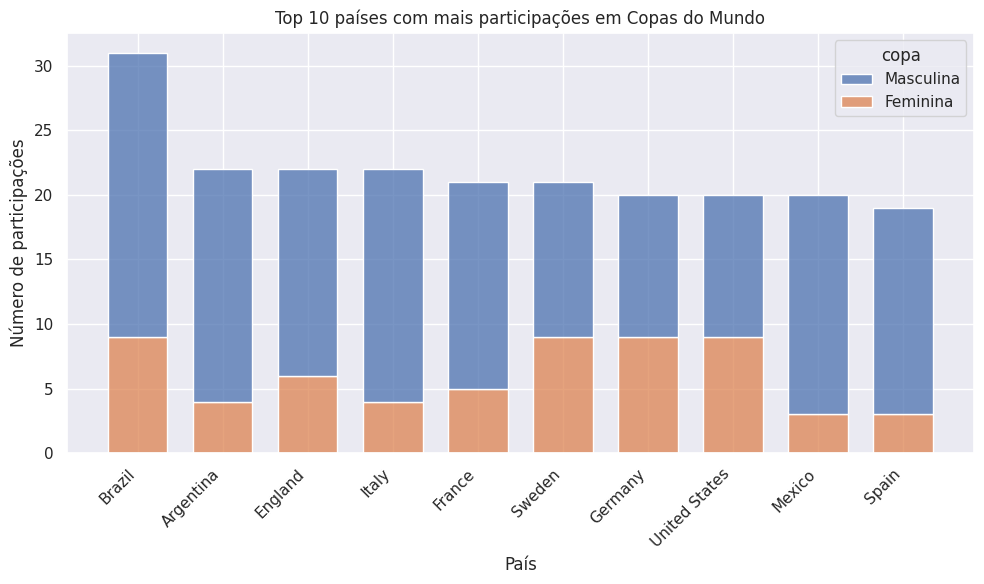

In [9]:
#### solução com seaborn

# seaborn não tem uma função de barra empilhada pronta, mas dá pra conseguir
# o mesmo resultado com histplot usando os num_copas como peso (weights) e
# empilhando por cor (multiple='stack')
participacao_top10 = participacao[participacao['país'].isin(top10_paises.index)].copy()

# fixa a ordem dos países no eixo x seguindo o ranking do total (maior pra menor)
ordem_paises = top10_paises.index.tolist()
participacao_top10['país'] = pd.Categorical(participacao_top10['país'], categories=ordem_paises, ordered=True)

plt.figure(figsize=(10, 6))
sns.histplot(data=participacao_top10, x='país', weights='num_copas', hue='copa',
             multiple='stack', shrink=0.7, hue_order=['Masculina', 'Feminina'])
plt.title('Top 10 países com mais participações em Copas do Mundo')
plt.xlabel('País')
plt.ylabel('Número de participações')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [10]:
#### solução com plotly

participacao_top10_wide = top10_paises.reset_index()[['país', 'Masculina', 'Feminina']]

fig = px.bar(participacao_top10_wide, x='país', y=['Masculina', 'Feminina'],
             title='Top 10 países com mais participações em Copas do Mundo',
             labels={'value': 'Número de participações', 'país': 'País', 'variable': 'Copa'})
fig.show()


#### Q5.

Vamos fazer um compilado com as estatísticas históricas de copas do mundo!

Com a biblioteca de sua preferência você deve criar 4 subplots organizados em um grid de 2 linhas e 2 colunas. Eles devem conter os seguintes gráficos:
* Linha 1, coluna 1: Gráfico de barras com a quantidade de jogos que aconteceram por ano
* Linha 1, coluna 2: Gráfico de área (referências a seguir) com o total de gols por ano, separando as informações de `gols_1` e `gols_2` para distinguir gols em casa e do time visitante.
* Linha 2, coluna 1: Gráfico de área com o total de cartões por ano, separando as informações de cartões amarelos e cartões vermelhos, mas agregando cartões do time 1 ou time 2. Ou seja, uma área com `cartao_amarelo_1 + cartao_amarelo_2` e outra área com `cartao_vermelho_1 + cartao_vermelho_2`.
* Linha 2, coluna 2: Gráfico de barras com o total de gols contra por ano, somando `gols_contra_1` e `gols_contra_2`.

Referências sobre gráfico de área
* Matplotlib: https://matplotlib.org/stable/gallery/lines_bars_and_markers/stackplot_demo.html#sphx-glr-gallery-lines-bars-and-markers-stackplot-demo-py
* Pandas + Matplotlib: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.area.html
* Seaborn: https://seaborn.pydata.org/generated/seaborn.objects.Area.html
* Plotly: https://plotly.com/python/filled-area-plots/

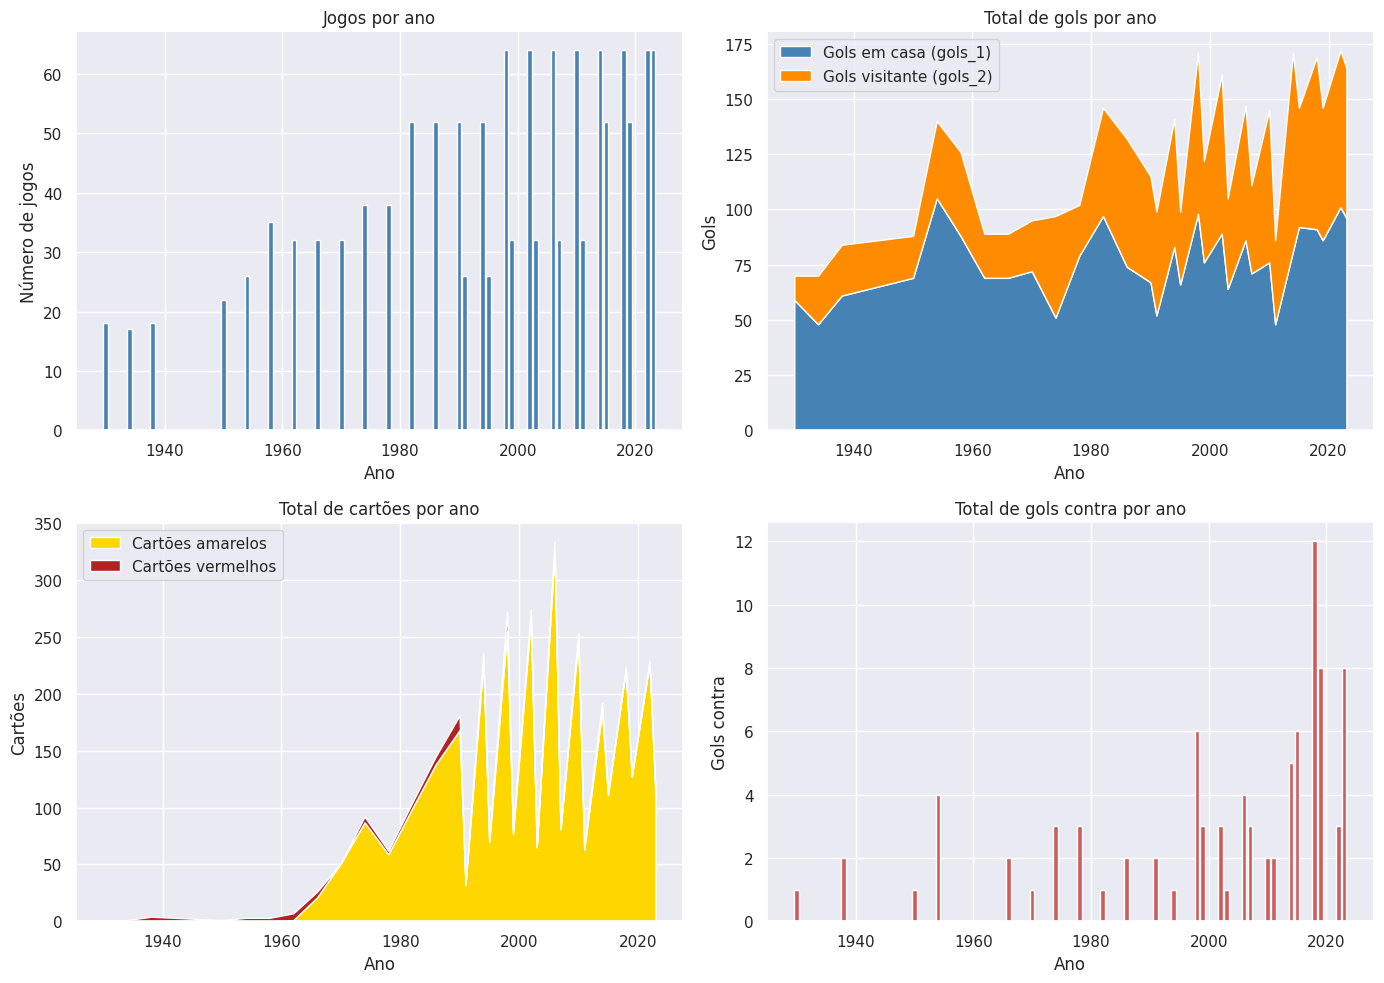

In [11]:
# vou usar matplotlib pra montar o painel, que é a biblioteca mais direta pra
# combinar vários tipos de gráfico (barra + área) num grid de subplots

# função genérica pra contar quantos itens tem em cada observação, já que
# algumas colunas guardam uma string de lista python (ex: cartao_amarelo)
# e outras guardam os itens separados só por '|' (ex: cartao_vermelho, gols_contra)
def contar_itens(valor):
    if pd.isna(valor):
        return 0
    if valor.startswith('['):
        return len(ast.literal_eval(valor))
    return len(valor.split('|'))

wc['num_amarelo_1'] = wc['cartao_amarelo_1'].apply(contar_itens)
wc['num_amarelo_2'] = wc['cartao_amarelo_2'].apply(contar_itens)
wc['num_vermelho_1'] = wc['cartao_vermelho_1'].apply(contar_itens)
wc['num_vermelho_2'] = wc['cartao_vermelho_2'].apply(contar_itens)
wc['num_contra_1'] = wc['gols_1_contra'].apply(contar_itens)
wc['num_contra_2'] = wc['gols_2_contra'].apply(contar_itens)

jogos_por_ano = wc.groupby('ano').size()
gols_por_ano = wc.groupby('ano')[['gols_1', 'gols_2']].sum()
cartoes_por_ano = pd.DataFrame({
    'amarelo': wc.groupby('ano')[['num_amarelo_1', 'num_amarelo_2']].sum().sum(axis=1),
    'vermelho': wc.groupby('ano')[['num_vermelho_1', 'num_vermelho_2']].sum().sum(axis=1),
})
gols_contra_por_ano = wc.groupby('ano')[['num_contra_1', 'num_contra_2']].sum().sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# linha 1, coluna 1 - jogos por ano
axes[0, 0].bar(jogos_por_ano.index, jogos_por_ano.values, color='steelblue')
axes[0, 0].set_title('Jogos por ano')
axes[0, 0].set_xlabel('Ano')
axes[0, 0].set_ylabel('Número de jogos')

# linha 1, coluna 2 - gols por ano (área empilhada, casa x visitante)
axes[0, 1].stackplot(gols_por_ano.index, gols_por_ano['gols_1'], gols_por_ano['gols_2'],
                      labels=['Gols em casa (gols_1)', 'Gols visitante (gols_2)'],
                      colors=['steelblue', 'darkorange'])
axes[0, 1].set_title('Total de gols por ano')
axes[0, 1].set_xlabel('Ano')
axes[0, 1].set_ylabel('Gols')
axes[0, 1].legend()

# linha 2, coluna 1 - cartões por ano (área empilhada, amarelo x vermelho)
axes[1, 0].stackplot(cartoes_por_ano.index, cartoes_por_ano['amarelo'], cartoes_por_ano['vermelho'],
                      labels=['Cartões amarelos', 'Cartões vermelhos'],
                      colors=['gold', 'firebrick'])
axes[1, 0].set_title('Total de cartões por ano')
axes[1, 0].set_xlabel('Ano')
axes[1, 0].set_ylabel('Cartões')
axes[1, 0].legend()

# linha 2, coluna 2 - gols contra por ano
axes[1, 1].bar(gols_contra_por_ano.index, gols_contra_por_ano.values, color='indianred')
axes[1, 1].set_title('Total de gols contra por ano')
axes[1, 1].set_xlabel('Ano')
axes[1, 1].set_ylabel('Gols contra')

plt.tight_layout()
plt.show()
